# Dataset Inspection: mass_action_3s_v3

Quick sanity checks on the generated dataset before committing GPU hours to training.
Verifies trajectory shapes, scale distributions, species/reaction diversity, and
visualizes sample trajectories.


In [1]:
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules
if COLAB:
    import os
    import subprocess

    _CLONE_DIR = "/content/CRN_Surrogate"
    if not os.path.exists(_CLONE_DIR):
        subprocess.check_call(
            [
                "git",
                "clone",
                "-q",
                "https://github.com/Mijan/CRN_Surrogate.git",
                _CLONE_DIR,
            ]
        )
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "-e", _CLONE_DIR]
        )
    sys.path.insert(0, _CLONE_DIR)
else:
    sys.path.insert(0, str(Path("../..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1. Load Dataset

In [2]:
import json

import wandb

api = wandb.Api()
artifact = api.artifact(
    "jan-mikelson-independent/crn-surrogate/mass_action_3s_v3_dataset:latest"
)
artifact_dir = Path(artifact.download())
print(f"Downloaded to: {artifact_dir}")
print(f"Contents: {[f.name for f in artifact_dir.iterdir()]}")

train_files = sorted(artifact_dir.glob("*_train.pt"))
val_files = sorted(artifact_dir.glob("*_val.pt"))
meta_files = sorted(artifact_dir.glob("*_meta.json"))

train_dataset = torch.load(train_files[0], weights_only=False)
val_dataset = torch.load(val_files[0], weights_only=False)

if meta_files:
    meta = json.loads(meta_files[0].read_text())
    print("\nMetadata:")
    print(f"  Seed: {meta.get('seed')}")
    print(f"  Train items: {meta.get('n_train')}")
    print(f"  Val items: {meta.get('n_val')}")
    if "train_meta" in meta:
        print(f"  Train pass rate: {meta['train_meta'].get('pass_rate', 'N/A'):.0%}")
        print(f"  Train timeouts: {meta['train_meta'].get('n_timeout', 'N/A')}")

print(f"\nLoaded: {len(train_dataset)} train, {len(val_dataset)} val")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jan/.netrc.
wandb: Downloading large artifact 'mass_action_3s_v3_dataset:latest', 426.10MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:39.5 (10.8MB/s)


Downloaded to: /home/jan/Dropbox/personal_projects/CRN_Surrogate/experiments/analysis/artifacts/mass_action_3s_v3_dataset:v1
Contents: ['mass_action_3s_v3_val.pt', 'mass_action_3s_v3_train.pt', 'mass_action_3s_v3_meta.json']

Metadata:
  Seed: 42
  Train items: 50000
  Val items: 5000
  Train pass rate: 383%
  Train timeouts: 0

Loaded: 50000 train, 5000 val


## 2. Shape and Structure Checks

In [3]:
# Check first few items
print(
    f"{'idx':>5} {'n_sp':>5} {'n_rxn':>6} {'M':>4} {'T':>4} {'init_shape':>12} {'has_scale':>10}"
)
print("-" * 55)
for i in range(min(10, len(train_dataset))):
    item = train_dataset[i]
    t = item.trajectories
    n_sp = item.crn_repr.n_species
    n_rxn = item.crn_repr.n_reactions
    M, T, S = t.shape
    has_scale = hasattr(item, "scale") and item.scale is not None
    print(
        f"{i:>5} {n_sp:>5} {n_rxn:>6} {M:>4} {T:>4} {str(tuple(item.initial_state.shape)):>12} {str(has_scale):>10}"
    )

# Verify all items have consistent time grids
t0 = train_dataset[0].times
all_same_times = all(
    torch.equal(train_dataset[i].times, t0) for i in range(len(train_dataset))
)
print(f"\nAll items share the same time grid: {all_same_times}")
print(f"Time range: [{t0[0]:.1f}, {t0[-1]:.1f}], {len(t0)} points")

  idx  n_sp  n_rxn    M    T   init_shape  has_scale
-------------------------------------------------------
    0     1      4   16   50         (1,)       True
    1     1      4   16   50         (1,)       True
    2     1      4   16   50         (1,)       True
    3     1      4   16   50         (1,)       True
    4     1      3   16   50         (1,)       True
    5     1      3   16   50         (1,)       True
    6     1      3   16   50         (1,)       True
    7     1      3   16   50         (1,)       True
    8     2      6   16   50         (2,)       True
    9     2      6   16   50         (2,)       True

All items share the same time grid: True
Time range: [0.0, 20.0], 50 points


## 3. Dataset Statistics

In [4]:
def compute_stats(dataset, label=""):
    n_species_list = []
    n_reactions_list = []
    traj_means = []
    traj_maxes = []
    traj_stds = []
    init_norms = []
    scales = []

    for item in dataset:
        n_species_list.append(item.crn_repr.n_species)
        n_reactions_list.append(item.crn_repr.n_reactions)
        t = item.trajectories
        traj_means.append(t.mean().item())
        traj_maxes.append(t.max().item())
        traj_stds.append(t.std().item())
        init_norms.append(item.initial_state.norm().item())
        if hasattr(item, "scale") and item.scale is not None:
            scales.append(item.scale.max().item())

    print(f"--- {label} ({len(dataset)} items) ---")
    print(f"Species:  {dict(zip(*np.unique(n_species_list, return_counts=True)))}")
    print(f"Reactions: {dict(zip(*np.unique(n_reactions_list, return_counts=True)))}")
    print(
        f"Traj mean:  min={min(traj_means):.2f}, median={np.median(traj_means):.2f}, max={max(traj_means):.2f}"
    )
    print(
        f"Traj max:   min={min(traj_maxes):.1f}, median={np.median(traj_maxes):.1f}, max={max(traj_maxes):.1f}"
    )
    print(
        f"Traj std:   min={min(traj_stds):.2f}, median={np.median(traj_stds):.2f}, max={max(traj_stds):.2f}"
    )
    print(
        f"Init norm:  min={min(init_norms):.2f}, median={np.median(init_norms):.2f}, max={max(init_norms):.2f}"
    )
    if scales:
        print(
            f"Scale max:  min={min(scales):.2f}, median={np.median(scales):.2f}, max={max(scales):.2f}"
        )
    print()

    return {
        "n_species": n_species_list,
        "n_reactions": n_reactions_list,
        "traj_means": traj_means,
        "traj_maxes": traj_maxes,
        "init_norms": init_norms,
        "scales": scales,
    }


train_stats = compute_stats(train_dataset, "Train")
val_stats = compute_stats(val_dataset, "Val")

--- Train (50000 items) ---
Species:  {np.int64(1): np.int64(12972), np.int64(2): np.int64(18238), np.int64(3): np.int64(18790)}
Reactions: {np.int64(2): np.int64(2745), np.int64(3): np.int64(9180), np.int64(4): np.int64(13724), np.int64(5): np.int64(13229), np.int64(6): np.int64(9020), np.int64(7): np.int64(2006), np.int64(8): np.int64(96)}
Traj mean:  min=0.05, median=4.59, max=95337.93
Traj max:   min=1.0, median=30.0, max=100086.0
Traj std:   min=0.22, median=5.73, max=49829.32
Init norm:  min=0.00, median=20.59, max=2223.02
Scale max:  min=1.00, median=8.12, max=95659.17

--- Val (5000 items) ---
Species:  {np.int64(1): np.int64(1350), np.int64(2): np.int64(1834), np.int64(3): np.int64(1816)}
Reactions: {np.int64(2): np.int64(276), np.int64(3): np.int64(987), np.int64(4): np.int64(1376), np.int64(5): np.int64(1262), np.int64(6): np.int64(899), np.int64(7): np.int64(196), np.int64(8): np.int64(4)}
Traj mean:  min=0.05, median=4.65, max=92682.06
Traj max:   min=1.0, median=30.0, max

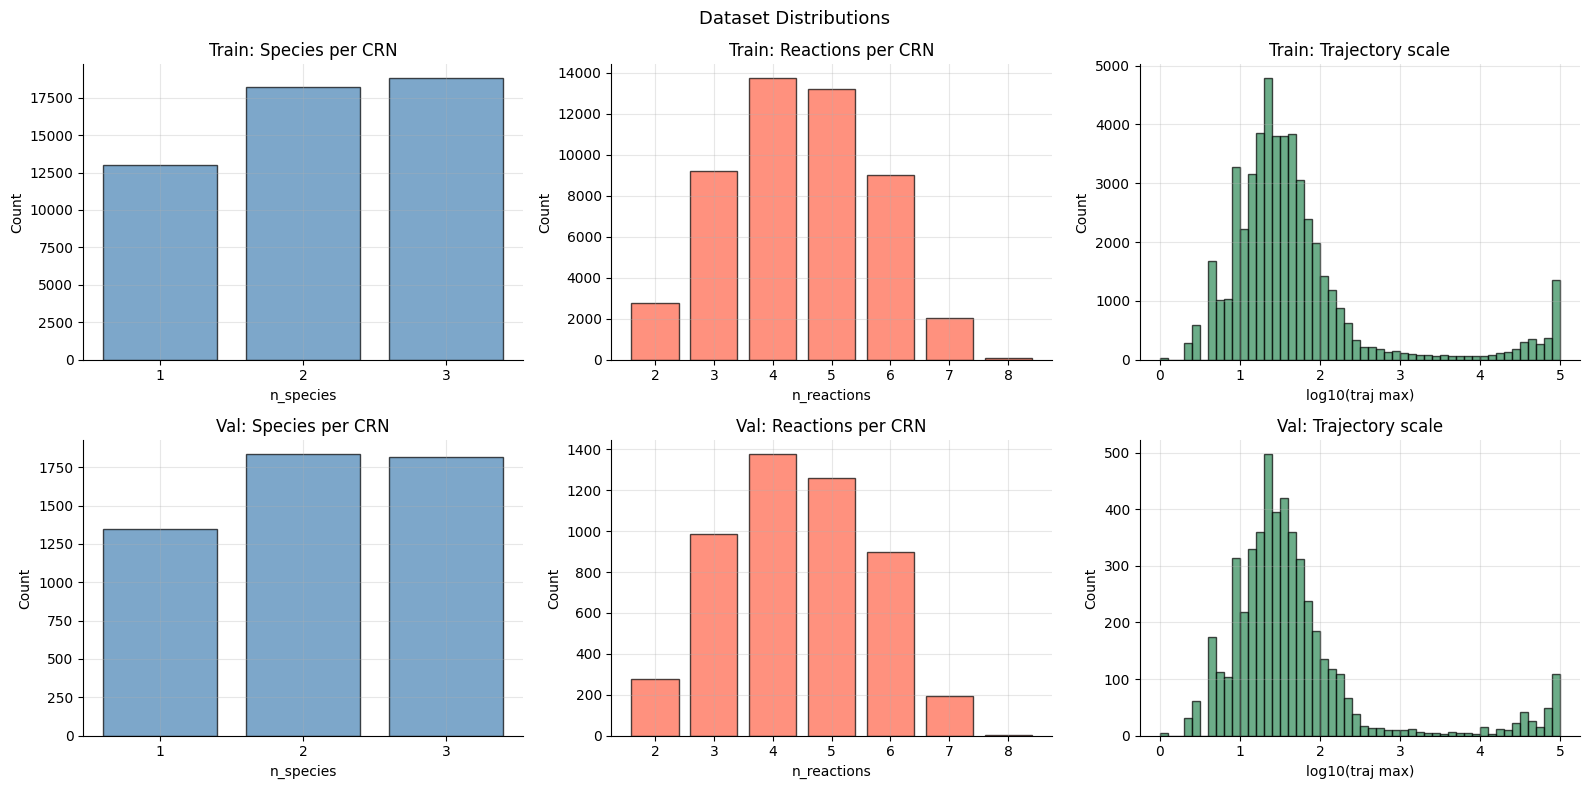

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Species distribution
for ax, stats, label in [
    (axes[0, 0], train_stats, "Train"),
    (axes[1, 0], val_stats, "Val"),
]:
    vals, counts = np.unique(stats["n_species"], return_counts=True)
    ax.bar(vals, counts, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_xlabel("n_species")
    ax.set_ylabel("Count")
    ax.set_title(f"{label}: Species per CRN")
    ax.set_xticks(vals)

# Reactions distribution
for ax, stats, label in [
    (axes[0, 1], train_stats, "Train"),
    (axes[1, 1], val_stats, "Val"),
]:
    vals, counts = np.unique(stats["n_reactions"], return_counts=True)
    ax.bar(vals, counts, color="tomato", edgecolor="black", alpha=0.7)
    ax.set_xlabel("n_reactions")
    ax.set_ylabel("Count")
    ax.set_title(f"{label}: Reactions per CRN")
    ax.set_xticks(vals)

# Trajectory max distribution (log scale)
for ax, stats, label in [
    (axes[0, 2], train_stats, "Train"),
    (axes[1, 2], val_stats, "Val"),
]:
    ax.hist(
        np.log10(np.clip(stats["traj_maxes"], 1e-1, None)),
        bins=50,
        color="seagreen",
        edgecolor="black",
        alpha=0.7,
    )
    ax.set_xlabel("log10(traj max)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label}: Trajectory scale")

plt.suptitle("Dataset Distributions", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Normalization Scale Distribution

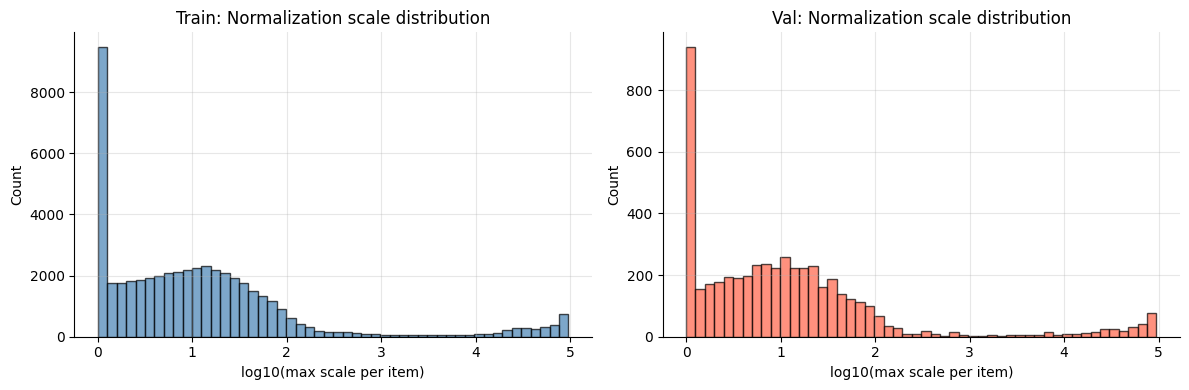

Items with scale clamped to 1.0 (low-count species): 7884/50000


In [6]:
if train_stats["scales"]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        np.log10(np.clip(train_stats["scales"], 1e-1, None)),
        bins=50,
        color="steelblue",
        edgecolor="black",
        alpha=0.7,
    )
    axes[0].set_xlabel("log10(max scale per item)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Train: Normalization scale distribution")

    axes[1].hist(
        np.log10(np.clip(val_stats["scales"], 1e-1, None)),
        bins=50,
        color="tomato",
        edgecolor="black",
        alpha=0.7,
    )
    axes[1].set_xlabel("log10(max scale per item)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Val: Normalization scale distribution")

    plt.tight_layout()
    plt.show()

    n_clamped = sum(1 for s in train_stats["scales"] if s <= 1.0)
    print(
        f"Items with scale clamped to 1.0 (low-count species): {n_clamped}/{len(train_stats['scales'])}"
    )
else:
    print("No precomputed scales in dataset items.")

## 5. Sample Trajectories

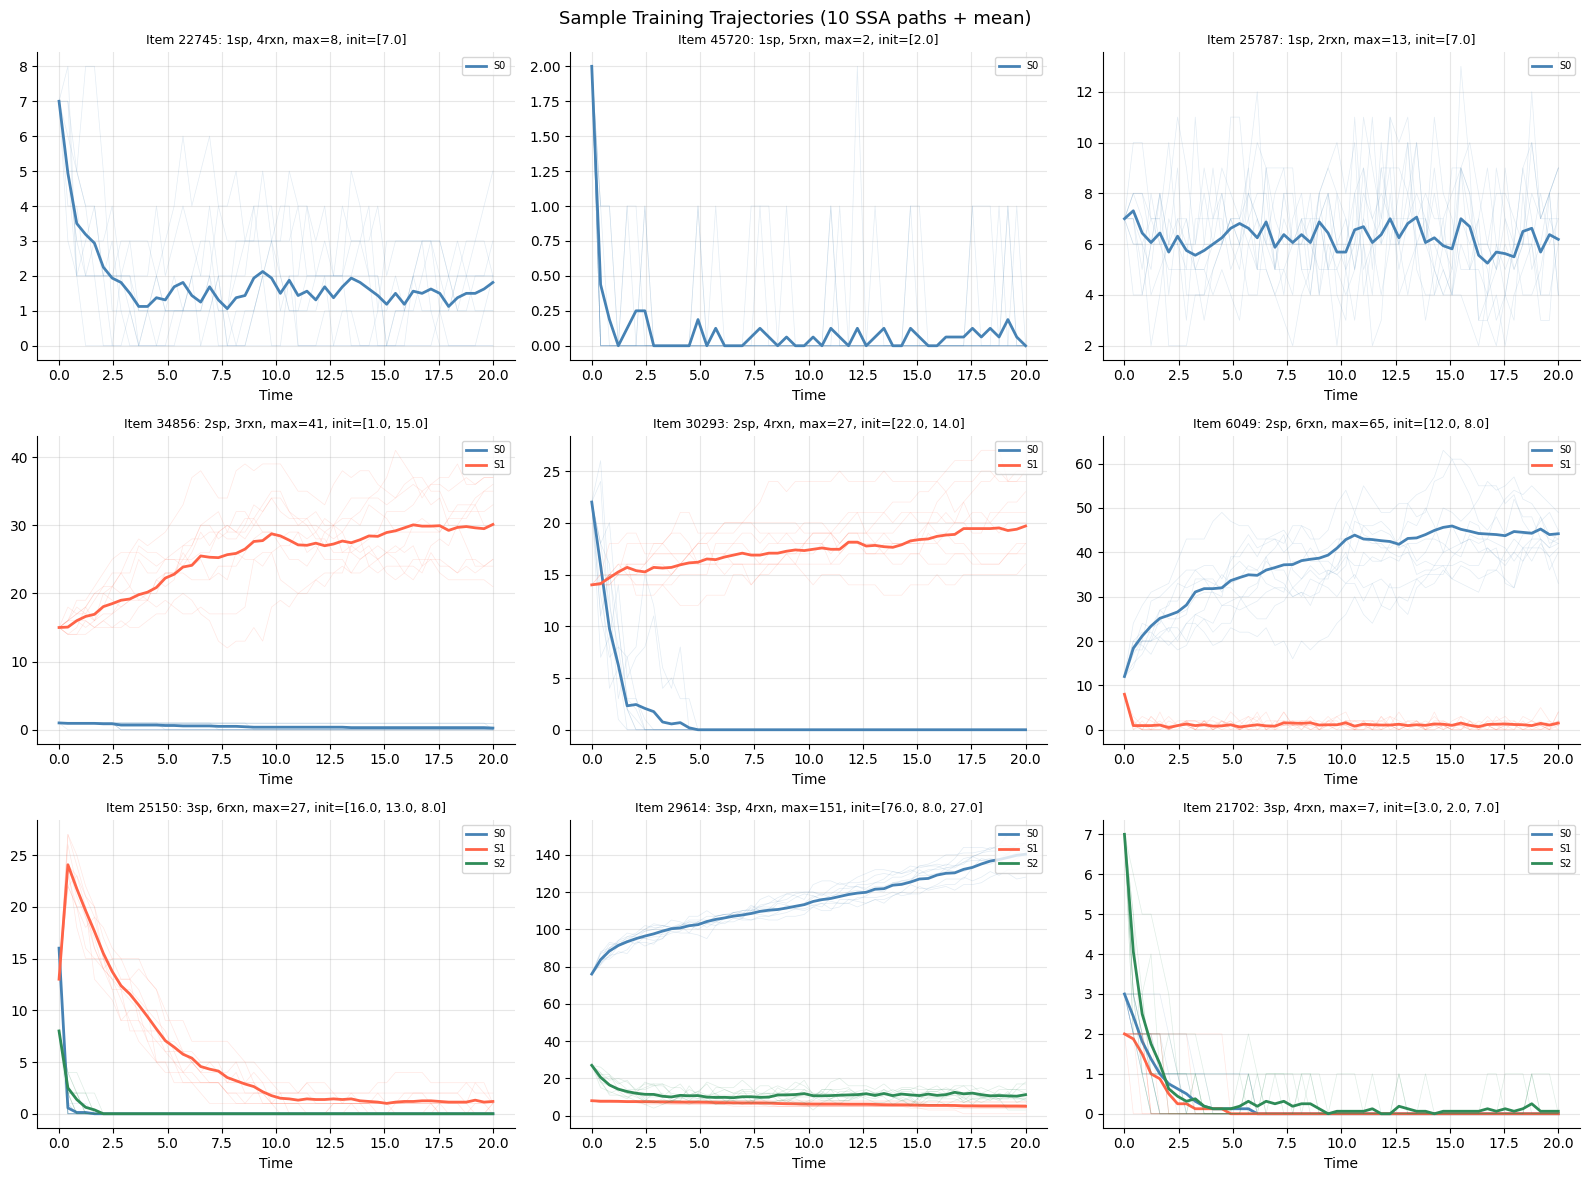

In [7]:
SPECIES_COLORS = ["steelblue", "tomato", "seagreen"]


def plot_item(item, ax, title=""):
    t = item.times.numpy()
    trajs = item.trajectories  # (M, T, n_species)
    M, T, n_sp = trajs.shape
    names = [f"S{s}" for s in range(n_sp)]

    for s in range(n_sp):
        color = SPECIES_COLORS[s % len(SPECIES_COLORS)]
        for m in range(min(M, 10)):
            ax.plot(t, trajs[m, :, s].numpy(), color=color, alpha=0.15, lw=0.5)
        ax.plot(
            t, trajs[:, :, s].mean(dim=0).numpy(), color=color, lw=2, label=names[s]
        )

    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlabel("Time")


# Pick diverse items: different species counts, spread across dataset
torch.manual_seed(42)
indices = []
for n_sp_target in [1, 2, 3]:
    candidates = [
        i
        for i in range(len(train_dataset))
        if train_dataset[i].crn_repr.n_species == n_sp_target
    ]
    if candidates:
        picked = [candidates[j] for j in torch.randperm(len(candidates))[:3].tolist()]
        indices.extend(picked)

n_plots = min(len(indices), 9)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes_flat = axes.flat if n_rows > 1 else [axes] if n_plots == 1 else axes

for ax_idx, item_idx in enumerate(indices[:n_plots]):
    item = train_dataset[item_idx]
    n_sp = item.crn_repr.n_species
    n_rxn = item.crn_repr.n_reactions
    tmax = item.trajectories.max().item()
    plot_item(
        item,
        axes_flat[ax_idx],
        title=f"Item {item_idx}: {n_sp}sp, {n_rxn}rxn, max={tmax:.0f}, "
        f"init={item.initial_state.tolist()}",
    )

for ax_idx in range(n_plots, len(list(axes_flat))):
    axes_flat[ax_idx].axis("off")

plt.suptitle("Sample Training Trajectories (10 SSA paths + mean)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Extreme Items (highest/lowest trajectory values)

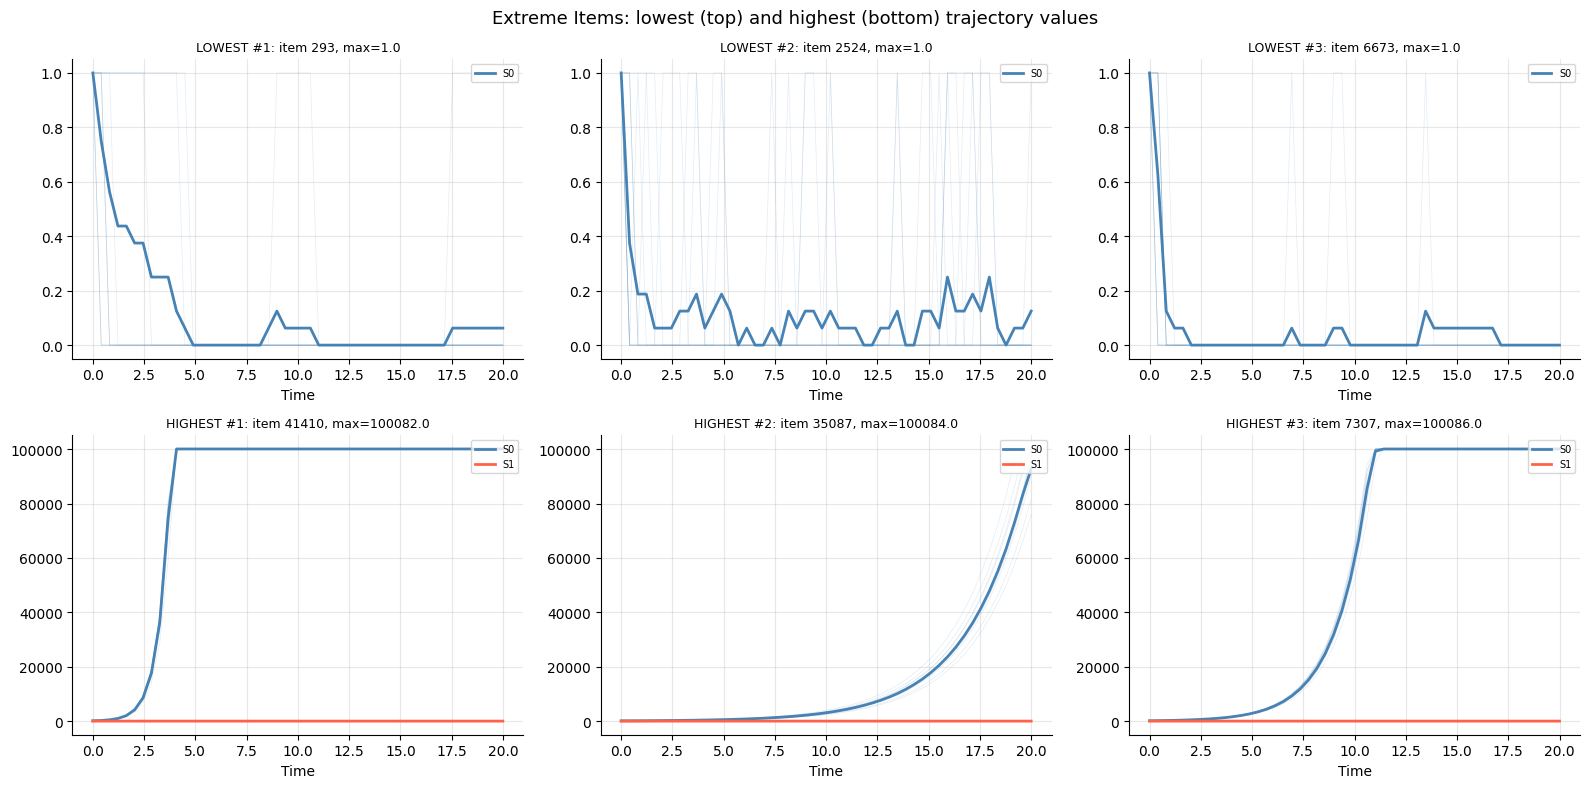

Lowest 5:
  Item 293: max=1.00, n_sp=1, n_rxn=3
  Item 2524: max=1.00, n_sp=1, n_rxn=3
  Item 6673: max=1.00, n_sp=1, n_rxn=5
  Item 7509: max=1.00, n_sp=1, n_rxn=5
  Item 8435: max=1.00, n_sp=1, n_rxn=4
Highest 5:
  Item 30097: max=100069.00, n_sp=2, n_rxn=5
  Item 20769: max=100077.00, n_sp=2, n_rxn=6
  Item 41410: max=100082.00, n_sp=2, n_rxn=4
  Item 35087: max=100084.00, n_sp=2, n_rxn=5
  Item 7307: max=100086.00, n_sp=2, n_rxn=5


In [8]:
# Find items with highest and lowest trajectory values
all_maxes = [
    (i, train_dataset[i].trajectories.max().item()) for i in range(len(train_dataset))
]
all_maxes.sort(key=lambda x: x[1])

low_items = all_maxes[:3]
high_items = all_maxes[-3:]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (idx, mx) in enumerate(low_items):
    item = train_dataset[idx]
    plot_item(item, axes[0, col], title=f"LOWEST #{col + 1}: item {idx}, max={mx:.1f}")

for col, (idx, mx) in enumerate(high_items):
    item = train_dataset[idx]
    plot_item(item, axes[1, col], title=f"HIGHEST #{col + 1}: item {idx}, max={mx:.1f}")

plt.suptitle(
    "Extreme Items: lowest (top) and highest (bottom) trajectory values", fontsize=13
)
plt.tight_layout()
plt.show()

print("Lowest 5:")
for idx, mx in all_maxes[:5]:
    print(
        f"  Item {idx}: max={mx:.2f}, n_sp={train_dataset[idx].crn_repr.n_species}, "
        f"n_rxn={train_dataset[idx].crn_repr.n_reactions}"
    )
print("Highest 5:")
for idx, mx in all_maxes[-5:]:
    print(
        f"  Item {idx}: max={mx:.2f}, n_sp={train_dataset[idx].crn_repr.n_species}, "
        f"n_rxn={train_dataset[idx].crn_repr.n_reactions}"
    )

## 7. Validation Set Samples

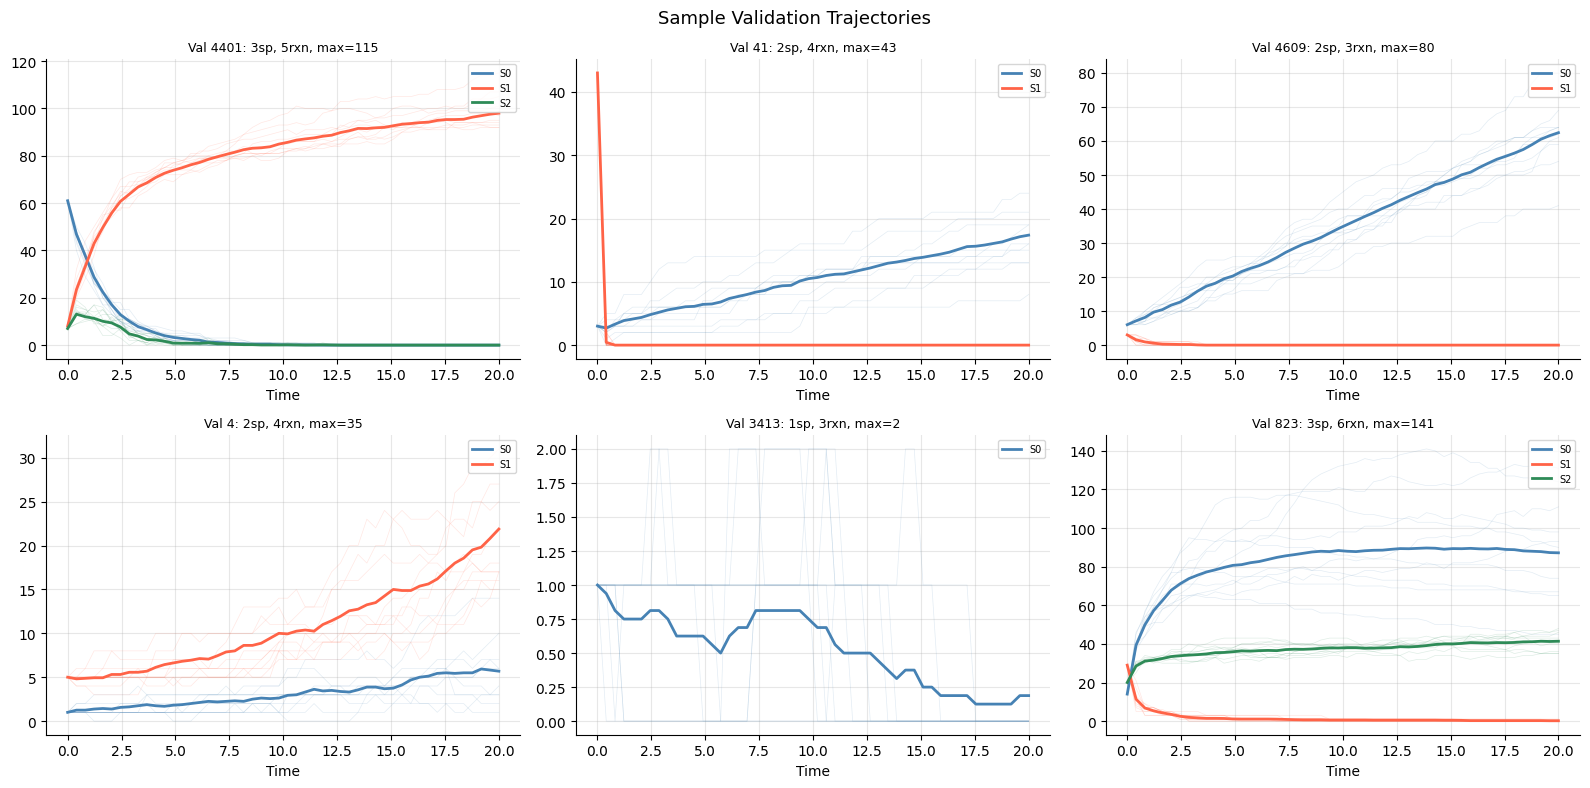

In [9]:
torch.manual_seed(99)
val_indices = torch.randperm(len(val_dataset))[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax_idx, item_idx in enumerate(val_indices):
    item = val_dataset[item_idx]
    n_sp = item.crn_repr.n_species
    n_rxn = item.crn_repr.n_reactions
    plot_item(
        item,
        axes.flat[ax_idx],
        title=f"Val {item_idx}: {n_sp}sp, {n_rxn}rxn, max={item.trajectories.max():.0f}",
    )

plt.suptitle("Sample Validation Trajectories", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Initial State Distribution

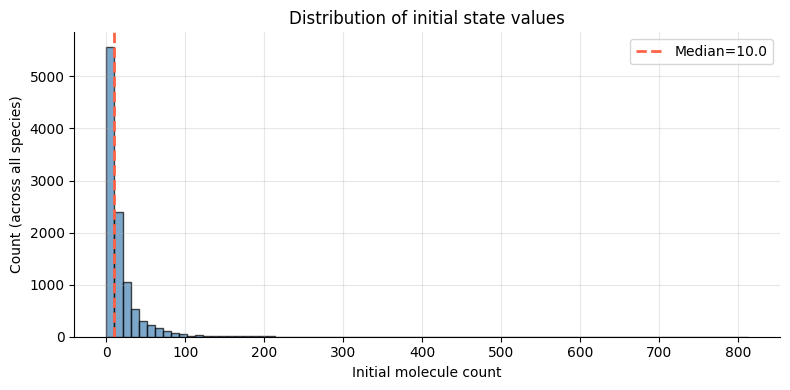

Initial state stats: min=0.0, median=10.0, max=812.0, mean=18.0


In [10]:
all_inits = []
for i in range(min(len(train_dataset), 5000)):  # cap to avoid OOM on huge datasets
    init = train_dataset[i].initial_state
    all_inits.extend(init.tolist())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_inits, bins=80, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_xlabel("Initial molecule count")
ax.set_ylabel("Count (across all species)")
ax.set_title("Distribution of initial state values")
ax.axvline(
    np.median(all_inits),
    color="tomato",
    ls="--",
    lw=2,
    label=f"Median={np.median(all_inits):.1f}",
)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Initial state stats: min={min(all_inits):.1f}, median={np.median(all_inits):.1f}, "
    f"max={max(all_inits):.1f}, mean={np.mean(all_inits):.1f}"
)

## Summary

Checklist:
- [ ] Species distribution covers 1, 2, and 3 species
- [ ] Reaction count distribution spans 2-6
- [ ] No extreme trajectory values (max should be <10k after curation)
- [ ] Initial states are diverse (log-normal spread)
- [ ] Normalization scales are reasonable (mostly 1-100)
- [ ] Train and val distributions look similar
- [ ] No obviously degenerate trajectories (flat, NaN, explosion)
